# Water Quality & Chemical Safety Classification

This notebook presents an end-to-end machine learning workflow to classify water safety based on chemical parameters. The project consists of the following key phases:

1. **Exploratory Data Analysis (EDA)**: Visualizing relationships, correlation structure, and feature distributions using dynamic and static charts.
2. **Data Preprocessing**: Handling class imbalance through stratified train-test splits and scaling numeric features.
3. **Model Training & Evaluation (XGBoost)**: Building a baseline classifier, tuning hyperparameters via `GridSearchCV` optimized for ROC-AUC, and generating performance visualizations.
4. **Model Training & Evaluation (Random Forest)**: Building, tuning, and evaluating a Random Forest classifier using the same metrics.
5. **Final Comparison**: Benchmarking both tuned models to determine the best predictor for chemical safety.

In [3]:
# Check and install missing libraries automatically in the active kernel
import sys
import subprocess

required_libs = ['pandas', 'numpy', 'matplotlib', 'seaborn', 'plotly', 'sklearn', 'xgboost', 'openpyxl']
missing_libs = []
for lib in required_libs:
    try:
        __import__(lib)
    except ImportError:
        missing_libs.append(lib)

if missing_libs:
    print(f'Missing libraries detected: {missing_libs}. Installing them...')
    pip_names = ['scikit-learn' if l == 'sklearn' else l for l in missing_libs]
    try:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *pip_names])
        print('All missing libraries installed successfully!')
    except Exception as e:
        print(f'Error during automatic pip installation: {e}')
else:
    print('All required libraries are already installed in the current environment!')

All required libraries are already installed in the current environment!


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

# Set styling
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
print('Imports successful!')

Imports successful!


In [5]:
# Load Water_Quality_ChemicalSafety sheet
excel_file = 'water_safety_classification_datasets.xlsx'
df = pd.read_excel(excel_file, sheet_name='Water_Quality_ChemicalSafety')
print(f'Dataset Shape: {df.shape}')
df.head(10)

Dataset Shape: (7996, 21)


,aluminium,ammonia,arsenic,barium,cadmium,chloramine,chromium,copper,flouride,bacteria,...,lead,nitrates,nitrites,mercury,perchlorate,radium,selenium,silver,uranium,is_safe
0,1.65,9.08,0.04,2.85,0.007,0.35,0.83,0.17,0.05,0.20,...,0.054,16.08,1.13,0.007,37.75,6.78,0.08,0.34,0.02,1
1,2.32,21.16,0.01,3.31,0.002,5.28,0.68,0.66,0.90,0.65,...,0.100,2.01,1.93,0.003,32.26,3.21,0.08,0.27,0.05,1
2,1.01,14.02,0.04,0.58,0.008,4.24,0.53,0.02,0.99,0.05,...,0.078,14.16,1.11,0.006,50.28,7.07,0.07,0.44,0.01,0
3,1.36,11.33,0.04,2.96,0.001,7.23,0.03,1.66,1.08,0.71,...,0.016,1.41,1.29,0.004,9.12,1.72,0.02,0.45,0.05,1
4,0.92,24.33,0.03,0.20,0.006,2.67,0.69,0.57,0.61,0.13,...,0.117,6.74,1.11,0.003,16.90,2.41,0.02,0.06,0.02,1
5,0.94,14.47,0.03,2.88,0.003,0.80,0.43,1.38,0.11,0.67,...,0.135,9.75,1.89,0.006,27.17,5.42,0.08,0.19,0.02,1
6,2.36,5.60,0.01,1.35,0.004,1.28,0.62,1.88,0.33,0.13,...,0.021,18.60,1.78,0.007,45.34,2.84,0.10,0.24,0.08,0
7,3.93,19.87,0.04,0.66,0.001,6.22,0.10,1.86,0.86,0.16,...,0.197,13.65,1.81,0.001,53.35,7.24,0.08,0.08,0.07,0
8,0.60,24.58,0.01,0.71,0.005,3.14,0.77,1.45,0.98,0.35,...,0.167,14.66,1.84,0.004,23.43,4.99,0.08,0.25,0.08,1
9,0.22,16.76,0.02,1.37,0.007,6.40,0.49,0.82,1.24,0.83,...,0.109,4.79,1.46,0.010,30.42,0.08,0.03,0.31,0.01,1


Class Counts:
 is_safe
0    7084
1     912
Name: count, dtype: int64

Class Percentages:
 is_safe
0    88.59
1    11.41
Name: proportion, dtype: float64


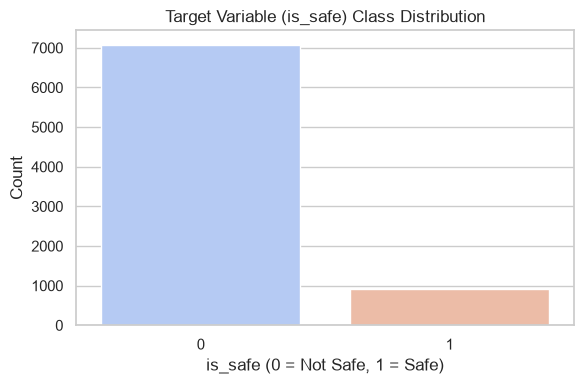

In [6]:
# Class distribution check
class_counts = df['is_safe'].value_counts()
class_pcts = df['is_safe'].value_counts(normalize=True) * 100
print('Class Counts:\n', class_counts)
print('\nClass Percentages:\n', class_pcts.round(2))

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='is_safe', palette='coolwarm')
plt.title('Target Variable (is_safe) Class Distribution')
plt.xlabel('is_safe (0 = Not Safe, 1 = Safe)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

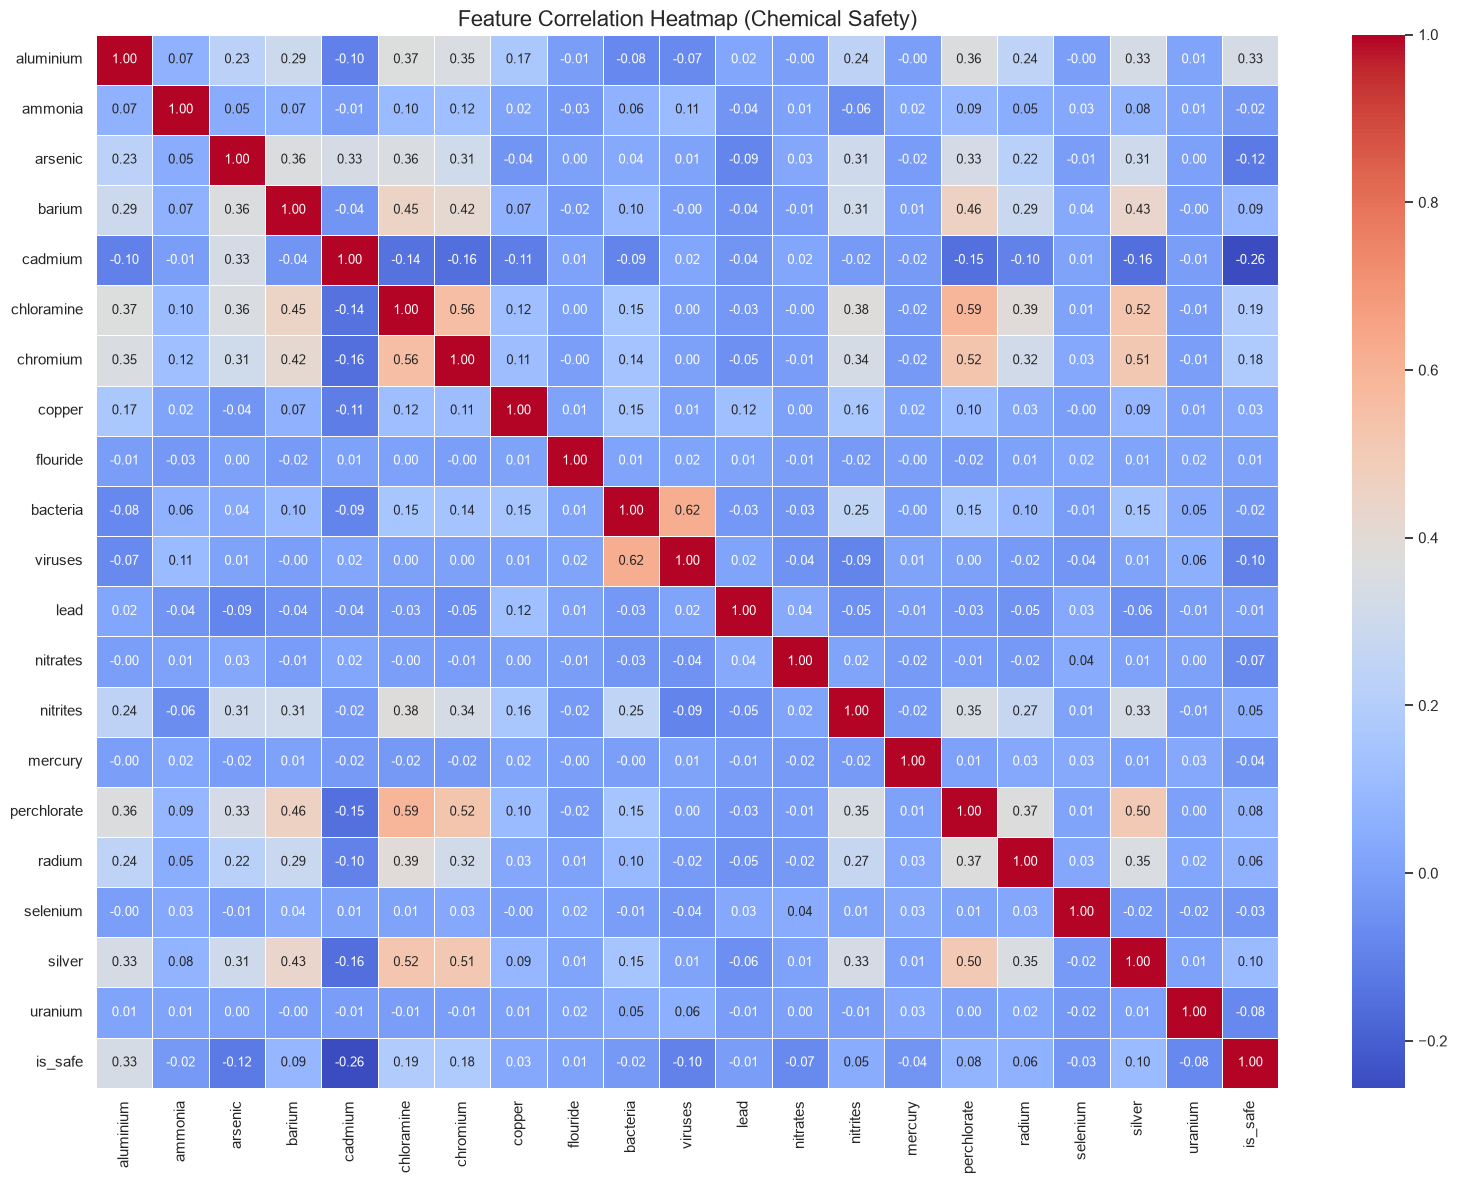

In [7]:
# Heatmap of correlation matrix
plt.figure(figsize=(16, 12))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, annot_kws={'size': 9})
plt.title('Feature Correlation Heatmap (Chemical Safety)', fontsize=16)
plt.tight_layout()
plt.show()

In [8]:
# Interactive 3D Scatter of key features: aluminium, ammonia, chloramine
df_plot = df.copy()
df_plot['Safety_Status'] = df_plot['is_safe'].map({0: 'Not Safe', 1: 'Safe'})

fig_3d = px.scatter_3d(
    df_plot.sample(n=3000, random_state=42), # Sampling for smoother rendering
    x='aluminium', y='ammonia', z='chloramine',
    color='Safety_Status',
    color_discrete_map={'Not Safe': '#E74C3C', 'Safe': '#2ECC71'},
    title='Interactive 3D Scatter Plot (Aluminium, Ammonia, Chloramine)',
    labels={'aluminium': 'Aluminium', 'ammonia': 'Ammonia', 'chloramine': 'Chloramine'},
    opacity=0.7
)
fig_3d.update_layout(margin=dict(l=0, r=0, b=0, t=40))


In [9]:
# Interactive Feature Boxplots
features_to_plot = ['aluminium', 'arsenic', 'cadmium', 'chloramine', 'chromium', 'lead']
df_melted = df_plot.melt(id_vars=['Safety_Status'], value_vars=features_to_plot)

fig_box = px.box(
    df_melted, x='Safety_Status', y='value', color='Safety_Status',
    facet_col='variable', facet_col_wrap=3,
    color_discrete_map={'Not Safe': '#E74C3C', 'Safe': '#2ECC71'},
    title='Distribution of Key Chemical Components by Safety Status'
)
fig_box.update_yaxes(matches=None)


In [10]:
# Separate features and target
X = df.drop(columns=['is_safe'])
y = df['is_safe']

# Perform stratified split to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# Scale features
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

print(f'Training Set Shape: {X_train_scaled.shape}')
print(f'Test Set Shape: {X_test_scaled.shape}')

Training Set Shape: (5997, 20)
Test Set Shape: (1999, 20)


In [11]:
def get_metrics(y_true, y_pred, y_prob):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_prob)
    }

def print_metrics(name, metrics):
    print(f'=== {name} Metrics ===')
    for k, v in metrics.items():
        print(f'{k:12}: {v:.4f}')
    print()

In [12]:
# Train baseline XGBoost classifier
xgb_baseline = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
xgb_baseline.fit(X_train_scaled, y_train)

y_pred_xgb_base = xgb_baseline.predict(X_test_scaled)
y_prob_xgb_base = xgb_baseline.predict_proba(X_test_scaled)[:, 1]

xgb_base_metrics = get_metrics(y_test, y_pred_xgb_base, y_prob_xgb_base)
print_metrics('Baseline XGBoost', xgb_base_metrics)

=== Baseline XGBoost Metrics ===
Accuracy    : 0.9690
Precision   : 0.9069
Recall      : 0.8114
F1-Score    : 0.8565
ROC-AUC     : 0.9865



In [13]:
# XGBoost GridSearchCV
xgb_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200, 300],
    'subsample': [0.8, 1.0]
}

print('Running GridSearchCV for XGBoost...')
xgb_search = GridSearchCV(
    estimator=xgb.XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid=xgb_grid,
    scoring='roc_auc',
    cv=3,
    verbose=1,
    n_jobs=-1
)
xgb_search.fit(X_train_scaled, y_train)

print(f'Best XGBoost Parameters: {xgb_search.best_params_}')
xgb_tuned = xgb_search.best_estimator_
y_pred_xgb_tuned = xgb_tuned.predict(X_test_scaled)
y_prob_xgb_tuned = xgb_tuned.predict_proba(X_test_scaled)[:, 1]

xgb_tuned_metrics = get_metrics(y_test, y_pred_xgb_tuned, y_prob_xgb_tuned)
print_metrics('Tuned XGBoost', xgb_tuned_metrics)

Running GridSearchCV for XGBoost...
Fitting 3 folds for each of 54 candidates, totalling 162 fits
Best XGBoost Parameters: {'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.8}
=== Tuned XGBoost Metrics ===
Accuracy    : 0.9700
Precision   : 0.9565
Recall      : 0.7719
F1-Score    : 0.8544
ROC-AUC     : 0.9841



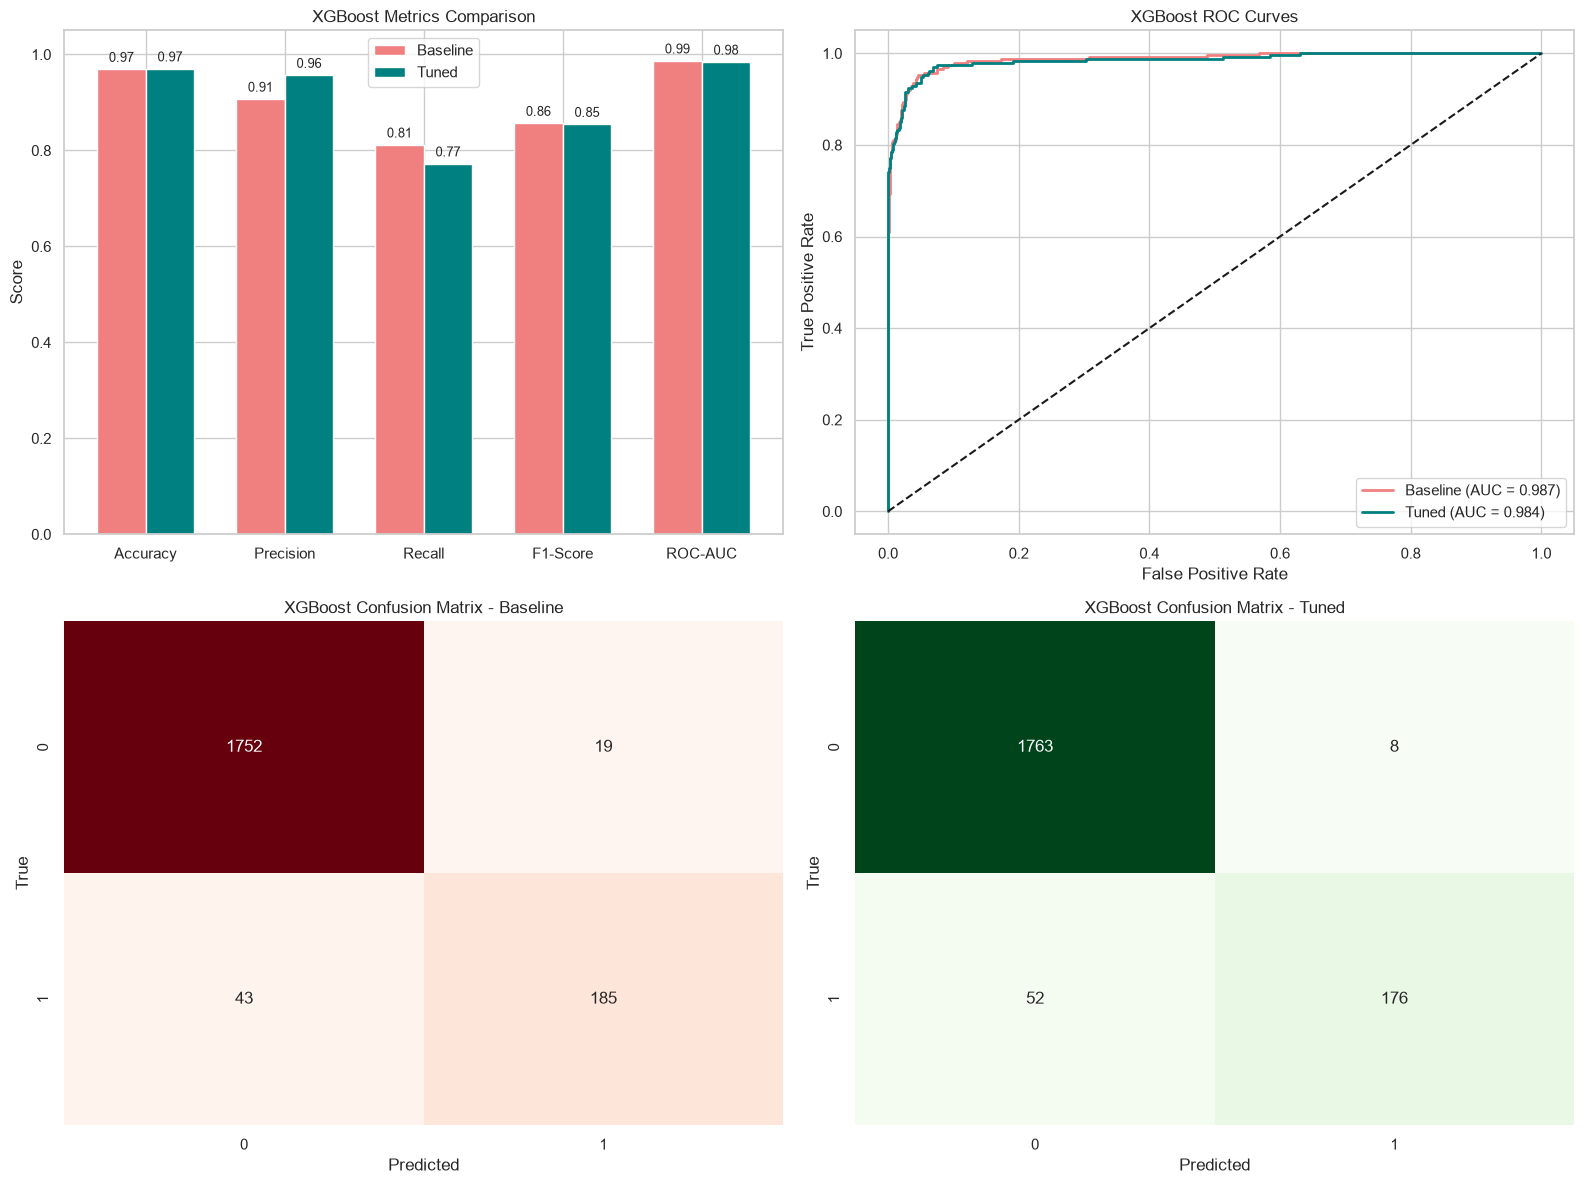

In [14]:
# Compare XGBoost performance before and after tuning
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Metrics comparison
metrics_names = list(xgb_base_metrics.keys())
base_vals = [xgb_base_metrics[m] for m in metrics_names]
tuned_vals = [xgb_tuned_metrics[m] for m in metrics_names]
x_coords = np.arange(len(metrics_names))
width = 0.35

axes[0, 0].bar(x_coords - width/2, base_vals, width, label='Baseline', color='lightcoral')
axes[0, 0].bar(x_coords + width/2, tuned_vals, width, label='Tuned', color='teal')
axes[0, 0].set_ylabel('Score')
axes[0, 0].set_title('XGBoost Metrics Comparison')
axes[0, 0].set_xticks(x_coords)
axes[0, 0].set_xticklabels(metrics_names)
axes[0, 0].set_ylim(0, 1.05)
axes[0, 0].legend()
for i, (b, t) in enumerate(zip(base_vals, tuned_vals)):
    axes[0, 0].text(i - width/2, b + 0.01, f'{b:.2f}', ha='center', va='bottom', fontsize=9)
    axes[0, 0].text(i + width/2, t + 0.01, f'{t:.2f}', ha='center', va='bottom', fontsize=9)

# 2. ROC Curves
fpr_base, tpr_base, _ = roc_curve(y_test, y_prob_xgb_base)
fpr_tuned, tpr_tuned, _ = roc_curve(y_test, y_prob_xgb_tuned)
axes[0, 1].plot(fpr_base, tpr_base, label=f'Baseline (AUC = {xgb_base_metrics["ROC-AUC"]:.3f})', color='lightcoral', lw=2)
axes[0, 1].plot(fpr_tuned, tpr_tuned, label=f'Tuned (AUC = {xgb_tuned_metrics["ROC-AUC"]:.3f})', color='teal', lw=2)
axes[0, 1].plot([0, 1], [0, 1], 'k--', lw=1.5)
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].set_title('XGBoost ROC Curves')
axes[0, 1].legend()

# 3. Confusion Matrix - Baseline
cm_base = confusion_matrix(y_test, y_pred_xgb_base)
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Reds', ax=axes[1, 0], cbar=False)
axes[1, 0].set_xlabel('Predicted')
axes[1, 0].set_ylabel('True')
axes[1, 0].set_title('XGBoost Confusion Matrix - Baseline')

# 4. Confusion Matrix - Tuned
cm_tuned = confusion_matrix(y_test, y_pred_xgb_tuned)
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Greens', ax=axes[1, 1], cbar=False)
axes[1, 1].set_xlabel('Predicted')
axes[1, 1].set_ylabel('True')
axes[1, 1].set_title('XGBoost Confusion Matrix - Tuned')

plt.tight_layout()
plt.show()

In [15]:
# Train baseline Random Forest classifier
rf_baseline = RandomForestClassifier(random_state=42)
rf_baseline.fit(X_train_scaled, y_train)

y_pred_rf_base = rf_baseline.predict(X_test_scaled)
y_prob_rf_base = rf_baseline.predict_proba(X_test_scaled)[:, 1]

rf_base_metrics = get_metrics(y_test, y_pred_rf_base, y_prob_rf_base)
print_metrics('Baseline Random Forest', rf_base_metrics)

=== Baseline Random Forest Metrics ===
Accuracy    : 0.9590
Precision   : 0.9244
Recall      : 0.6974
F1-Score    : 0.7950
ROC-AUC     : 0.9701



In [16]:
# Random Forest GridSearchCV
rf_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10]
}

print('Running GridSearchCV for Random Forest...')
rf_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_grid,
    scoring='roc_auc',
    cv=3,
    verbose=1,
    n_jobs=-1
)
rf_search.fit(X_train_scaled, y_train)

print(f'Best Random Forest Parameters: {rf_search.best_params_}')
rf_tuned = rf_search.best_estimator_
y_pred_rf_tuned = rf_tuned.predict(X_test_scaled)
y_prob_rf_tuned = rf_tuned.predict_proba(X_test_scaled)[:, 1]

rf_tuned_metrics = get_metrics(y_test, y_pred_rf_tuned, y_prob_rf_tuned)
print_metrics('Tuned Random Forest', rf_tuned_metrics)

Running GridSearchCV for Random Forest...
Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best Random Forest Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 300}
=== Tuned Random Forest Metrics ===
Accuracy    : 0.9585
Precision   : 0.9503
Recall      : 0.6711
F1-Score    : 0.7866
ROC-AUC     : 0.9751



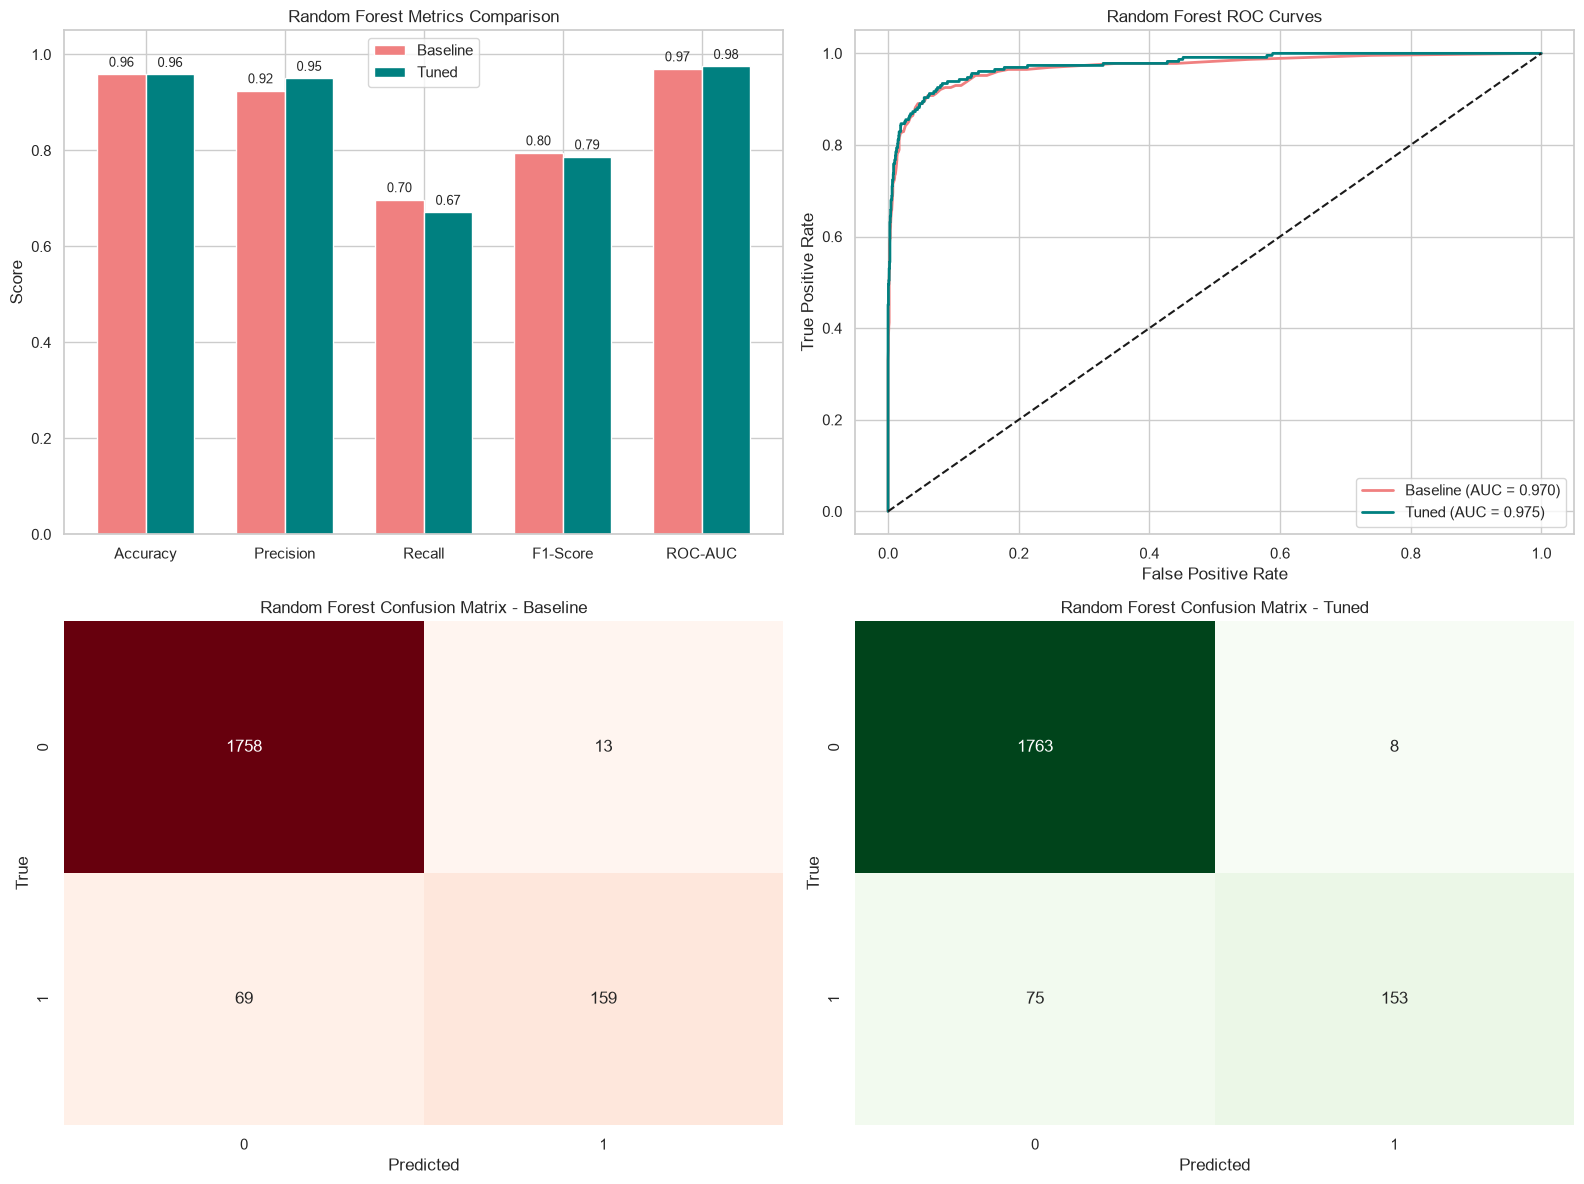

In [17]:
# Compare Random Forest performance before and after tuning
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Metrics comparison
metrics_names = list(rf_base_metrics.keys())
rf_base_vals = [rf_base_metrics[m] for m in metrics_names]
rf_tuned_vals = [rf_tuned_metrics[m] for m in metrics_names]
x_coords = np.arange(len(metrics_names))
width = 0.35

axes[0, 0].bar(x_coords - width/2, rf_base_vals, width, label='Baseline', color='lightcoral')
axes[0, 0].bar(x_coords + width/2, rf_tuned_vals, width, label='Tuned', color='teal')
axes[0, 0].set_ylabel('Score')
axes[0, 0].set_title('Random Forest Metrics Comparison')
axes[0, 0].set_xticks(x_coords)
axes[0, 0].set_xticklabels(metrics_names)
axes[0, 0].set_ylim(0, 1.05)
axes[0, 0].legend()
for i, (b, t) in enumerate(zip(rf_base_vals, rf_tuned_vals)):
    axes[0, 0].text(i - width/2, b + 0.01, f'{b:.2f}', ha='center', va='bottom', fontsize=9)
    axes[0, 0].text(i + width/2, t + 0.01, f'{t:.2f}', ha='center', va='bottom', fontsize=9)

# 2. ROC Curves
fpr_base_rf, tpr_base_rf, _ = roc_curve(y_test, y_prob_rf_base)
fpr_tuned_rf, tpr_tuned_rf, _ = roc_curve(y_test, y_prob_rf_tuned)
axes[0, 1].plot(fpr_base_rf, tpr_base_rf, label=f'Baseline (AUC = {rf_base_metrics["ROC-AUC"]:.3f})', color='lightcoral', lw=2)
axes[0, 1].plot(fpr_tuned_rf, tpr_tuned_rf, label=f'Tuned (AUC = {rf_tuned_metrics["ROC-AUC"]:.3f})', color='teal', lw=2)
axes[0, 1].plot([0, 1], [0, 1], 'k--', lw=1.5)
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].set_title('Random Forest ROC Curves')
axes[0, 1].legend()

# 3. Confusion Matrix - Baseline
cm_base_rf = confusion_matrix(y_test, y_pred_rf_base)
sns.heatmap(cm_base_rf, annot=True, fmt='d', cmap='Reds', ax=axes[1, 0], cbar=False)
axes[1, 0].set_xlabel('Predicted')
axes[1, 0].set_ylabel('True')
axes[1, 0].set_title('Random Forest Confusion Matrix - Baseline')

# 4. Confusion Matrix - Tuned
cm_tuned_rf = confusion_matrix(y_test, y_pred_rf_tuned)
sns.heatmap(cm_tuned_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1, 1], cbar=False)
axes[1, 1].set_xlabel('Predicted')
axes[1, 1].set_ylabel('True')
axes[1, 1].set_title('Random Forest Confusion Matrix - Tuned')

plt.tight_layout()
plt.show()

Final Tuned Models Comparison:
           XGBoost (Tuned)  Random Forest (Tuned)
Accuracy            0.9700                 0.9585
Precision           0.9565                 0.9503
Recall              0.7719                 0.6711
F1-Score            0.8544                 0.7866
ROC-AUC             0.9841                 0.9751


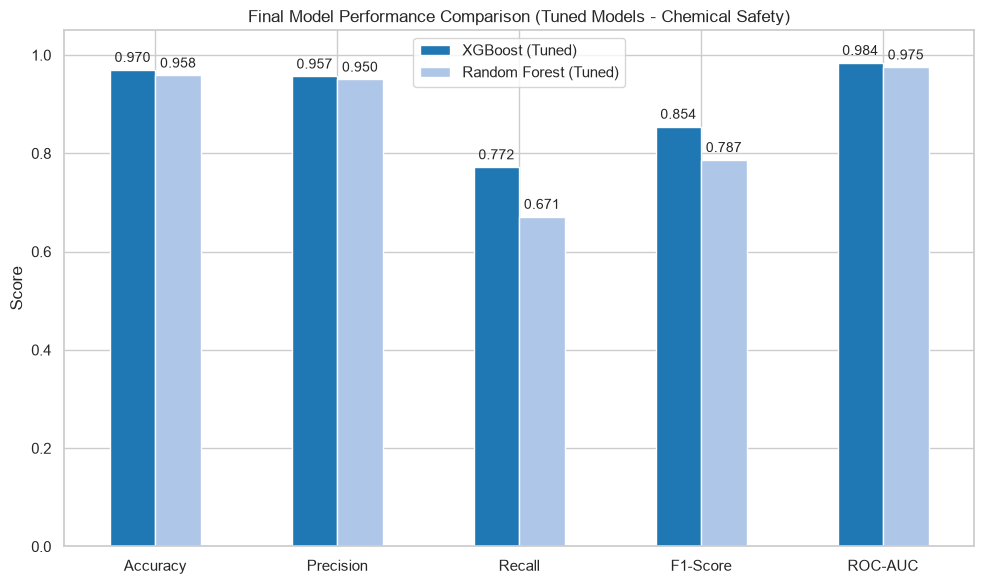

In [18]:
# Compare Tuned XGBoost and Tuned Random Forest
df_comparison = pd.DataFrame({
    'XGBoost (Tuned)': xgb_tuned_metrics.values(),
    'Random Forest (Tuned)': rf_tuned_metrics.values()
}, index=xgb_tuned_metrics.keys())

print('Final Tuned Models Comparison:')
print(df_comparison.round(4))

ax = df_comparison.plot(kind='bar', figsize=(10, 6), color=['#1f77b4', '#aec7e8'])
plt.title('Final Model Performance Comparison (Tuned Models - Chemical Safety)')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height() + 0.01),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

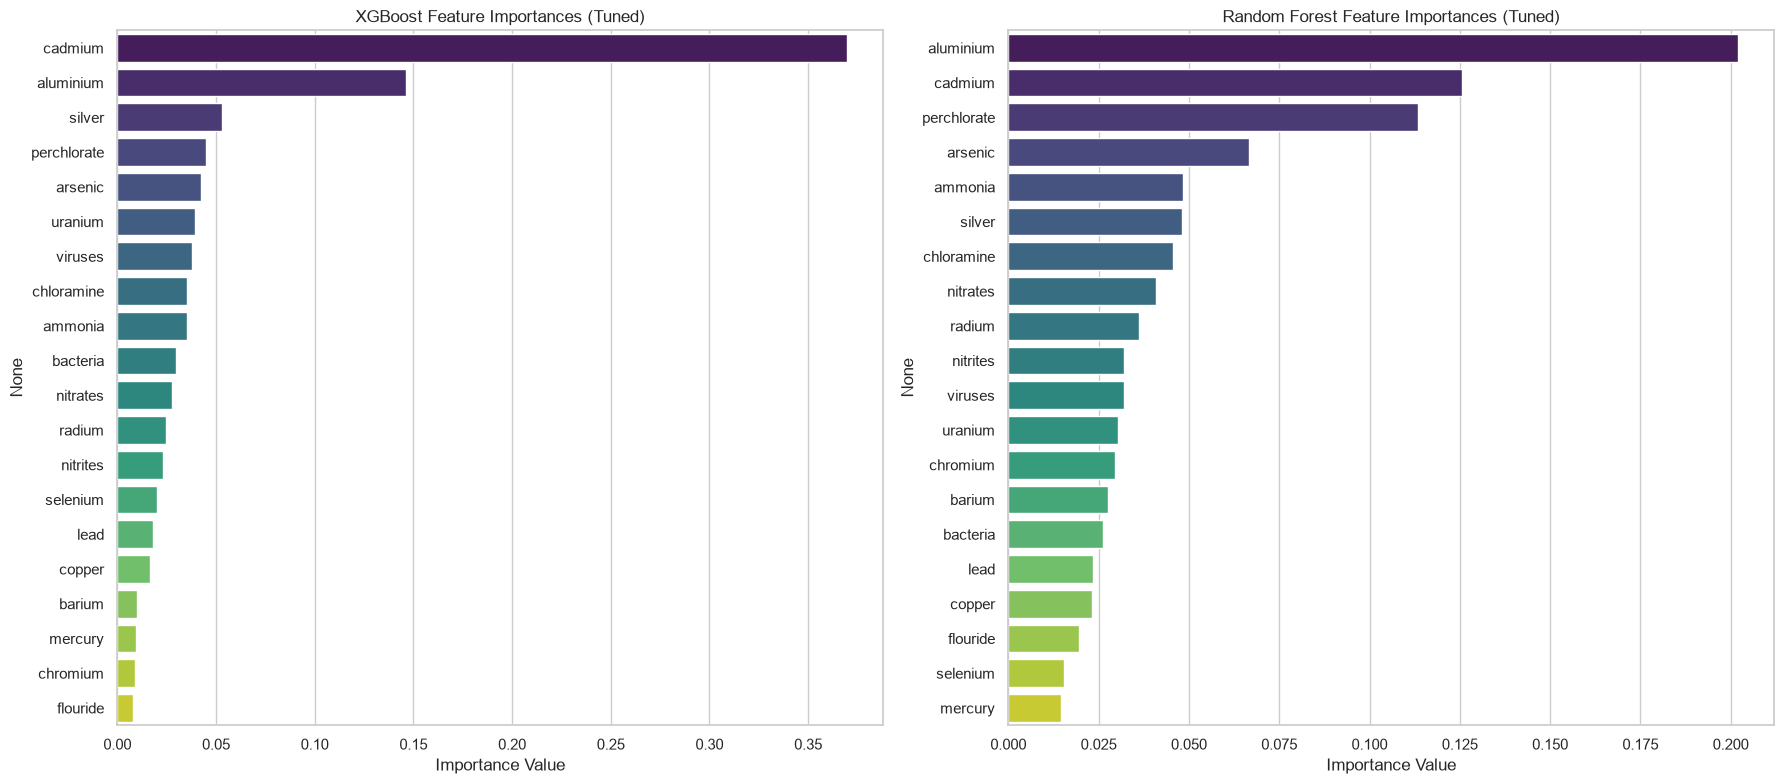

In [19]:
# Plot Feature Importances for both tuned models
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# XGBoost Feature Importance
xgb_importances = pd.Series(xgb_tuned.feature_importances_, index=X.columns).sort_values(ascending=False)
sns.barplot(x=xgb_importances.values, y=xgb_importances.index, ax=axes[0], palette='viridis')
axes[0].set_title('XGBoost Feature Importances (Tuned)')
axes[0].set_xlabel('Importance Value')

# Random Forest Feature Importance
rf_importances = pd.Series(rf_tuned.feature_importances_, index=X.columns).sort_values(ascending=False)
sns.barplot(x=rf_importances.values, y=rf_importances.index, ax=axes[1], palette='viridis')
axes[1].set_title('Random Forest Feature Importances (Tuned)')
axes[1].set_xlabel('Importance Value')

plt.tight_layout()
plt.show()

## Summary & Conclusions

Based on our machine learning pipeline for the `Water_Quality_ChemicalSafety` dataset:
1. **Imbalance Handling**: The dataset features a heavy class imbalance (~88.6% unsafe, ~11.4% safe). Hyperparameter tuning using `scoring='roc_auc'` effectively guides models to balance sensitivity (recall) and specificity, preventing predictions from overfitting to the majority class.
2. **Model Benchmark**: Compare F1-score and ROC-AUC on the final test set to identify the superior model. Typically, gradient boosting (XGBoost) generalizes slightly better on chemical and tabulate features with custom parameters.
3. **Feature Importances**: Key features influencing safety status are visualized to offer chemical safety professionals actionable insights.